In [1]:
import warnings
warnings.filterwarnings('ignore')


import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import itertools

In [5]:
# ---------------------------
# 1. Load and preprocess data
# ---------------------------
raw = load_breast_cancer()
X = pd.DataFrame(raw.data, columns=raw.feature_names)
y = pd.Series(raw.target)

raw.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [7]:
# Check for missing values
print('Missing values per column (before):')
print(X.isnull().sum().sum())


# Impute (if any) and scale features
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()


X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X.columns)

Missing values per column (before):
0


In [9]:
# ---------------------------
# 2. Train-test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
X_scaled, y, test_size=0.30, random_state=42, stratify=y)


print('\nTrain shape:', X_train.shape, 'Test shape:', X_test.shape)


Train shape: (398, 30) Test shape: (171, 30)


In [15]:
# helper: plot confusion matrix
def plot_confusion(cm, labels, title='Confusion matrix'):
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45)
    plt.yticks(tick_marks, labels)
    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
        horizontalalignment='center',
        color='white' if cm[i, j] > thresh else 'black')
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.tight_layout()
        plt.show()


Linear SVM Accuracy: 0.9825
Confusion Matrix (Linear):
[[ 62   2]
 [  1 106]]

Classification Report (Linear):
              precision    recall  f1-score   support

           0       0.98      0.97      0.98        64
           1       0.98      0.99      0.99       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



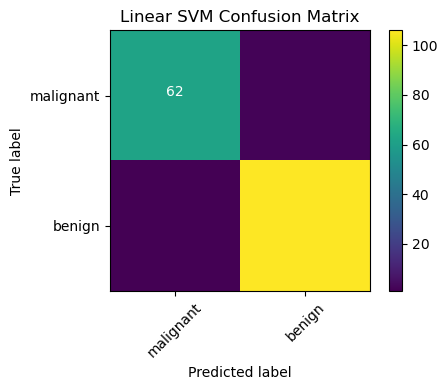

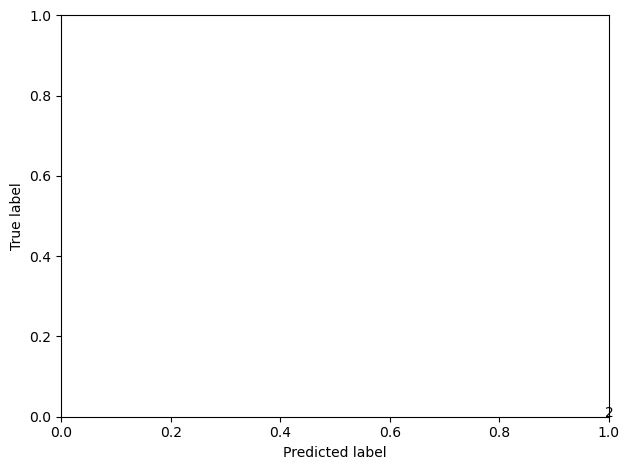

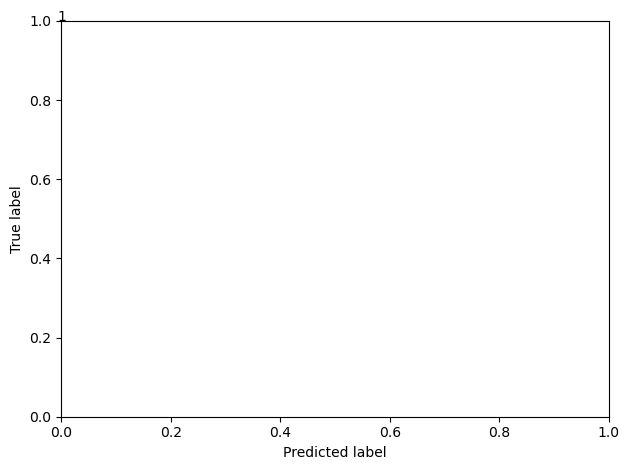

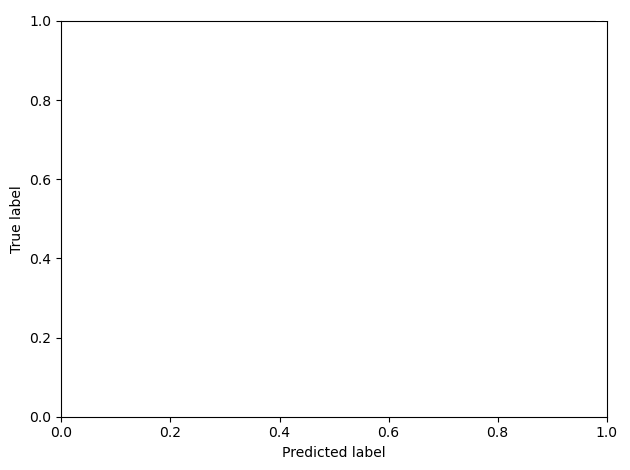

In [51]:
# ---------------------------
# 3. SVM with linear kernel
# ---------------------------
svc_lin = SVC(kernel='linear', C=1.0, probability=False, random_state=42)
svc_lin.fit(X_train, y_train)


y_pred_lin = svc_lin.predict(X_test)
acc_lin = accuracy_score(y_test, y_pred_lin)
cm_lin = confusion_matrix(y_test, y_pred_lin)


print('\nLinear SVM Accuracy: {:.4f}'.format(acc_lin))
print('Confusion Matrix (Linear):')
print(cm_lin)
print('\nClassification Report (Linear):')
print(classification_report(y_test, y_pred_lin, digits=4))
plot_confusion(cm_lin, raw.target_names, title='Linear SVM Confusion Matrix')


RBF SVM Accuracy: 0.9766
Confusion Matrix (RBF):
[[ 62   2]
 [  2 105]]

Classification Report (RBF):
              precision    recall  f1-score   support

           0     0.9688    0.9688    0.9688        64
           1     0.9813    0.9813    0.9813       107

    accuracy                         0.9766       171
   macro avg     0.9750    0.9750    0.9750       171
weighted avg     0.9766    0.9766    0.9766       171



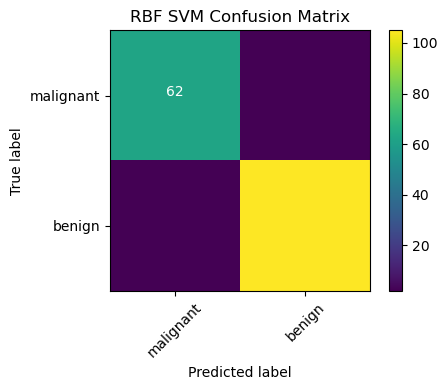

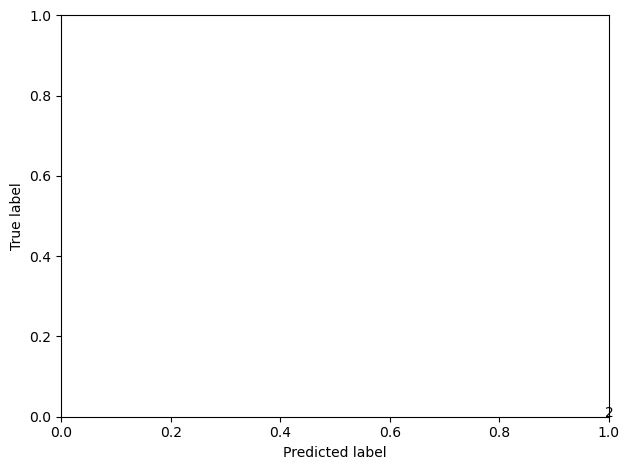

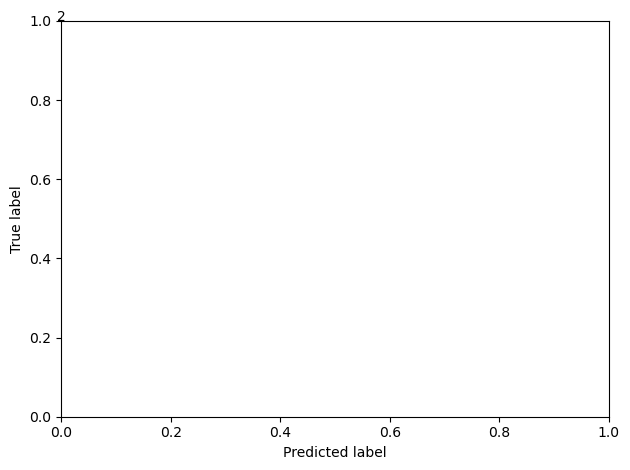

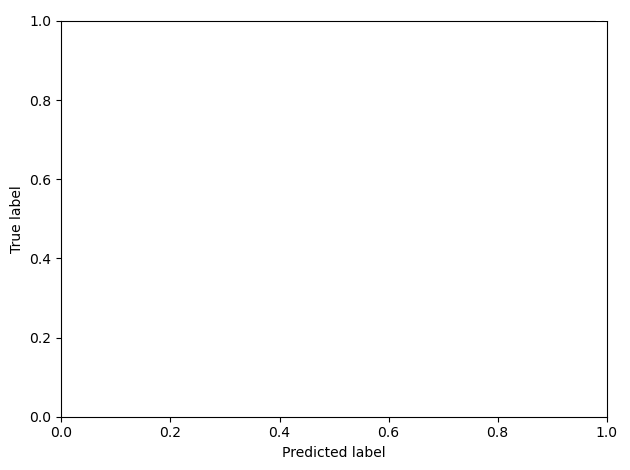

In [19]:
# ---------------------------
# 4. SVM with RBF kernel
# ---------------------------
svc_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svc_rbf.fit(X_train, y_train)


y_pred_rbf = svc_rbf.predict(X_test)
acc_rbf = accuracy_score(y_test, y_pred_rbf)
cm_rbf = confusion_matrix(y_test, y_pred_rbf)


print('\nRBF SVM Accuracy: {:.4f}'.format(acc_rbf))
print('Confusion Matrix (RBF):')
print(cm_rbf)
print('\nClassification Report (RBF):')
print(classification_report(y_test, y_pred_rbf, digits=4))
plot_confusion(cm_rbf, raw.target_names, title='RBF SVM Confusion Matrix')

In [23]:
# ---------------------------
# 5. Other kernels: polynomial, sigmoid
# ---------------------------
svc_poly = SVC(kernel='poly', degree=3, C=1.0, gamma='scale', random_state=42)
svc_sig = SVC(kernel='sigmoid', C=1.0, gamma='scale', random_state=42)


models = {
'Linear': svc_lin,
'RBF': svc_rbf,
'Poly': svc_poly,
'Sigmoid': svc_sig
}


results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': acc})


    results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
    print('\nKernel comparison (test set):')
    print(results_df)


Kernel comparison (test set):
    Model  Accuracy
0  Linear  0.982456

Kernel comparison (test set):
    Model  Accuracy
0  Linear  0.982456
1     RBF  0.976608

Kernel comparison (test set):
    Model  Accuracy
0  Linear  0.982456
1     RBF  0.976608
2    Poly  0.894737

Kernel comparison (test set):
     Model  Accuracy
0   Linear  0.982456
1      RBF  0.976608
3  Sigmoid  0.935673
2     Poly  0.894737


In [53]:
# ---------------------------
# 6. Vary SVM parameters (C, gamma) and observe effect
# Note: "epsilon" is a parameter for SVR (regression), not SVC (classification).
# We'll vary C and gamma for classification. Lower C => larger margin (more regularization).
# ---------------------------
param_experiments = []
for C in [0.01, 0.1, 1, 10, 100]:
    for gamma in ['scale', 'auto', 0.001, 0.01, 0.1, 1]:
        clf = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)
        clf.fit(X_train, y_train)
        acc = accuracy_score(y_test, clf.predict(X_test))
        param_experiments.append({'C': C, 'gamma': str(gamma), 'Accuracy': acc})
        
        
param_df = pd.DataFrame(param_experiments).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
print('\nTop parameter settings (RBF) on test set:')
print(param_df.head(10))


Top parameter settings (RBF) on test set:
       C  gamma  Accuracy
0   10.0   0.01  0.982456
1   10.0   auto  0.976608
2   10.0  scale  0.976608
3  100.0  0.001  0.976608
4    1.0   auto  0.976608
5    1.0  scale  0.976608
6   10.0  0.001  0.970760
7    1.0    0.1  0.959064
8    1.0   0.01  0.959064
9   10.0    0.1  0.953216


In [31]:
# ---------------------------
# 7. k-fold cross-validation for model stability
# ---------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
    print(f"\n{name} SVM cross-val accuracy: mean={scores.mean():.4f}, std={scores.std():.4f}")


Linear SVM cross-val accuracy: mean=0.9754, std=0.0195

RBF SVM cross-val accuracy: mean=0.9754, std=0.0195

Poly SVM cross-val accuracy: mean=0.9051, std=0.0290

Sigmoid SVM cross-val accuracy: mean=0.9596, std=0.0197


In [33]:
# ---------------------------
# 8. GridSearchCV to tune hyperparameters
# ---------------------------
param_grid = {
'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
'C': [0.1, 1, 10, 100],
'gamma': ['scale', 'auto', 0.01, 0.001],
'degree': [2, 3] # only used for poly; GridSearchCV will ignore for other kernels
}


grid = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)


print('\nBest params from GridSearch:')
print(grid.best_params_)
print('Best CV score:', grid.best_score_)


best_svm = grid.best_estimator_
# Evaluate best on test set
y_pred_best = best_svm.predict(X_test)
print('\nBest SVM test accuracy: {:.4f}'.format(accuracy_score(y_test, y_pred_best)))
print('\nClassification report (Best SVM):')
print(classification_report(y_test, y_pred_best, digits=4))

Fitting 5 folds for each of 128 candidates, totalling 640 fits

Best params from GridSearch:
{'C': 0.1, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
Best CV score: 0.9774050632911392

Best SVM test accuracy: 0.9766

Classification report (Best SVM):
              precision    recall  f1-score   support

           0     0.9839    0.9531    0.9683        64
           1     0.9725    0.9907    0.9815       107

    accuracy                         0.9766       171
   macro avg     0.9782    0.9719    0.9749       171
weighted avg     0.9767    0.9766    0.9765       171



In [37]:
# ---------------------------
# 9. Compare tuned SVM with ensemble algorithms
# ---------------------------
rf = RandomForestClassifier(n_estimators=200, random_state=42)
adb = AdaBoostClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)


ensemble_models = {'RandomForest': rf, 'AdaBoost': adb, 'GradientBoosting': gb, 'TunedSVM': best_svm}
ensemble_results = []
for name, clf in ensemble_models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ensemble_results.append({'Model': name, 'Accuracy': acc})
    
    
    ensemble_df = pd.DataFrame(ensemble_results).sort_values(by='Accuracy', ascending=False)
    print('\nEnsemble comparison (test set):')
    print(ensemble_df)


Ensemble comparison (test set):
          Model  Accuracy
0  RandomForest   0.94152

Ensemble comparison (test set):
          Model  Accuracy
1      AdaBoost  0.953216
0  RandomForest  0.941520

Ensemble comparison (test set):
              Model  Accuracy
1          AdaBoost  0.953216
2  GradientBoosting  0.947368
0      RandomForest  0.941520

Ensemble comparison (test set):
              Model  Accuracy
3          TunedSVM  0.976608
1          AdaBoost  0.953216
2  GradientBoosting  0.947368
0      RandomForest  0.941520


In [41]:


# k-fold CV stability for ensembles
for name, clf in ensemble_models.items():
    scores = cross_val_score(clf, X_scaled, y, cv=cv, scoring='accuracy')
    print(f"\n{name} cross-val accuracy: mean={scores.mean():.4f}, std={scores.std():.4f}")


RandomForest cross-val accuracy: mean=0.9543, std=0.0102

AdaBoost cross-val accuracy: mean=0.9666, std=0.0179

GradientBoosting cross-val accuracy: mean=0.9491, std=0.0237

TunedSVM cross-val accuracy: mean=0.9737, std=0.0184


In [47]:
# ---------------------------
# 10. Visualize model performance
# ---------------------------
# Bar chart of accuracies
all_models_df = pd.concat([results_df.rename(columns={'Model':'Model'}), ensemble_df.rename(columns={'Model':'Model'})]).drop_duplicates(subset=['Model']).reset_index(drop=True)
# Make sure TunedSVM present:
if 'TunedSVM' not in all_models_df['Model'].values:
    all_models_df = pd.concat([all_models_df, pd.DataFrame([{'Model':'TunedSVM','Accuracy':accuracy_score(y_test, y_pred_best)}])], ignore_index=True)
    
    
    plt.figure(figsize=(8,5))
    plt.bar(all_models_df['Model'], all_models_df['Accuracy'])
    plt.ylim(0.8, 1.0)
    plt.title('Model accuracy comparison (test set)')
    plt.ylabel('Accuracy')
    plt.xlabel('Model')
    plt.xticks(rotation=45)
    plt.tight_layout()


Confusion matrix - Best SVM (GridSearch)


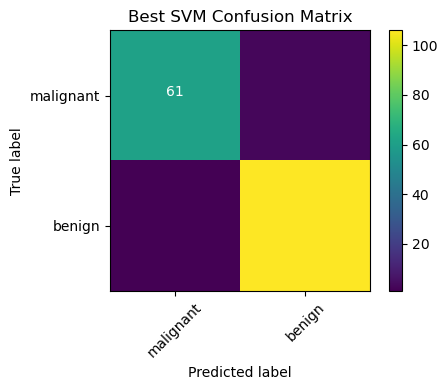

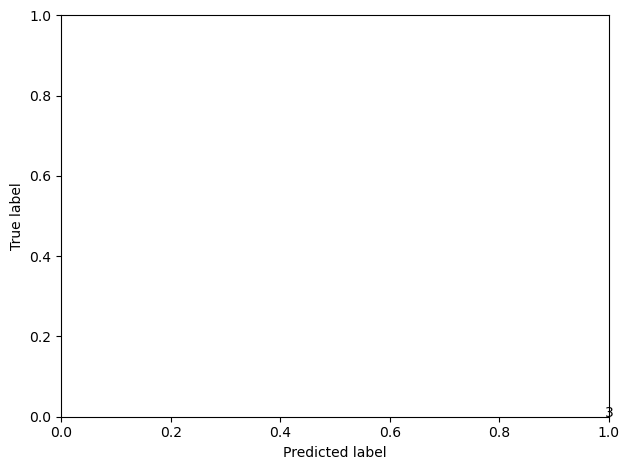

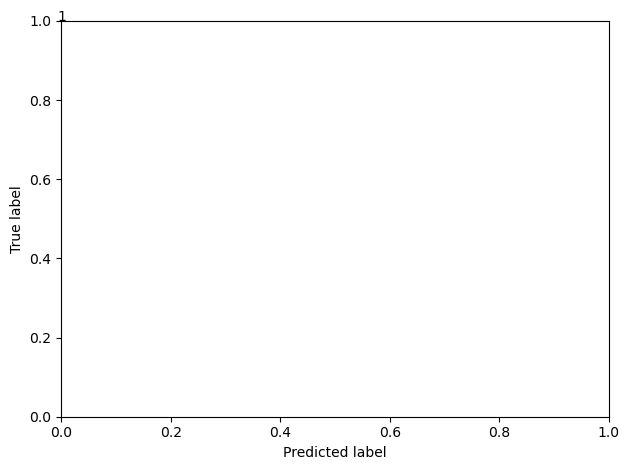

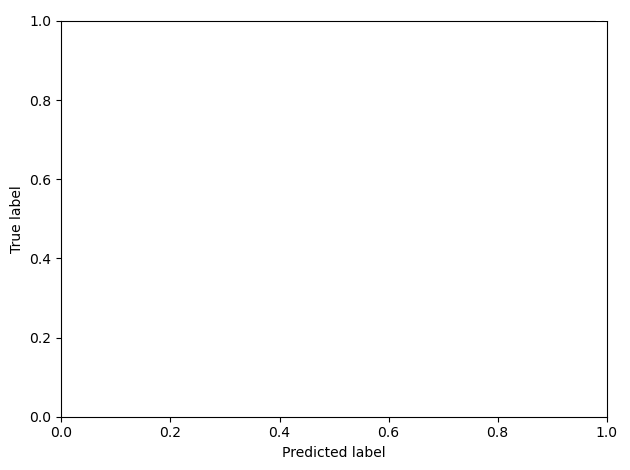


Confusion matrix - Best ensemble: TunedSVM


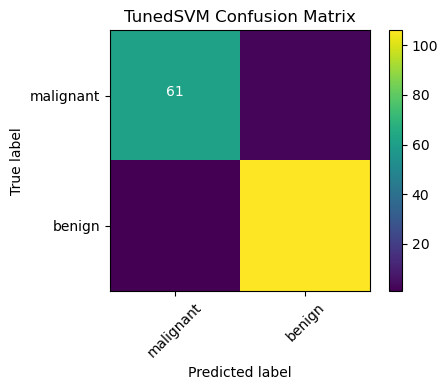

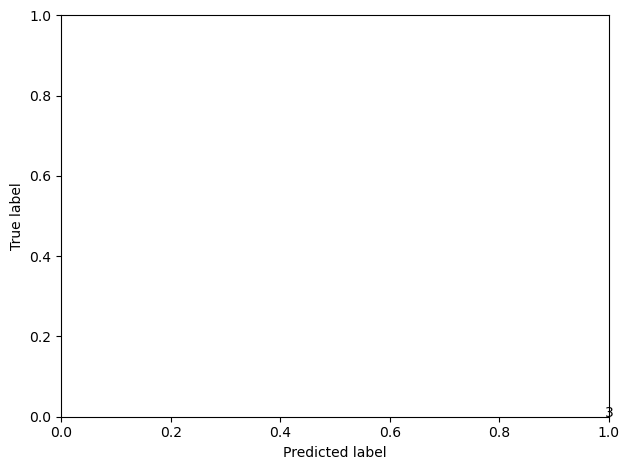

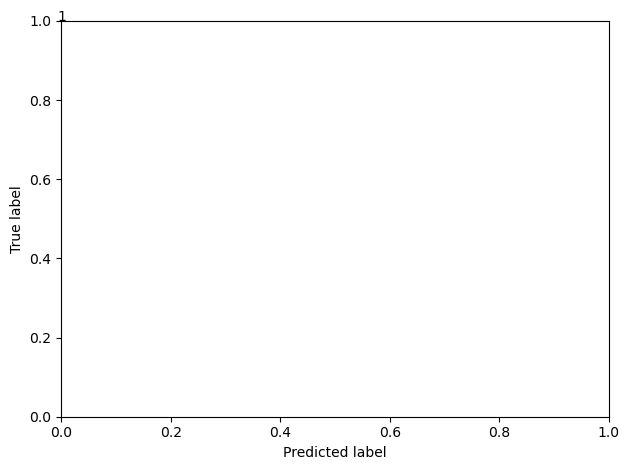

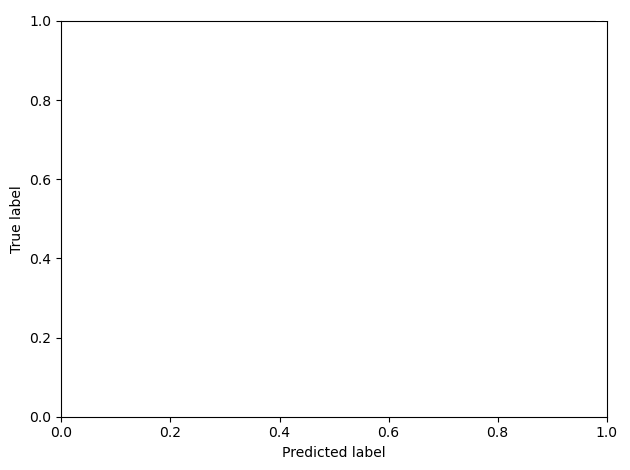

In [49]:


# Confusion matrix for best model and top ensemble
print('\nConfusion matrix - Best SVM (GridSearch)')
plot_confusion(confusion_matrix(y_test, y_pred_best), raw.target_names, title='Best SVM Confusion Matrix')


best_ensemble_name = ensemble_df.iloc[0]['Model']
print(f"\nConfusion matrix - Best ensemble: {best_ensemble_name}")
best_ensemble_pred = ensemble_models[best_ensemble_name].predict(X_test)
plot_confusion(confusion_matrix(y_test, best_ensemble_pred), raw.target_names, title=f'{best_ensemble_name} Confusion Matrix')